In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

import lightgbm as lgb

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
print(df.shape)
display(df.head())
display(df.info())

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

None

## Limpieza

In [3]:
df.columns = df.columns.str.strip()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df["SeniorCitizen"] = df["SeniorCitizen"].astype(str)

display(df.isna().sum().sort_values(ascending=False).head(10))
print(df["Churn"].value_counts(normalize=True))

TotalCharges        11
customerID           0
DeviceProtection     0
MonthlyCharges       0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
dtype: int64

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


## Distribución del target

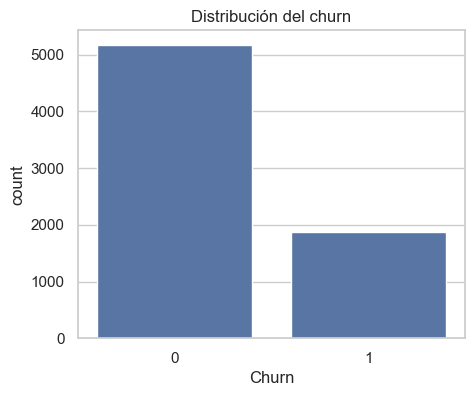

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Churn")
plt.title("Distribución del churn")
plt.show()

print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

## EDA

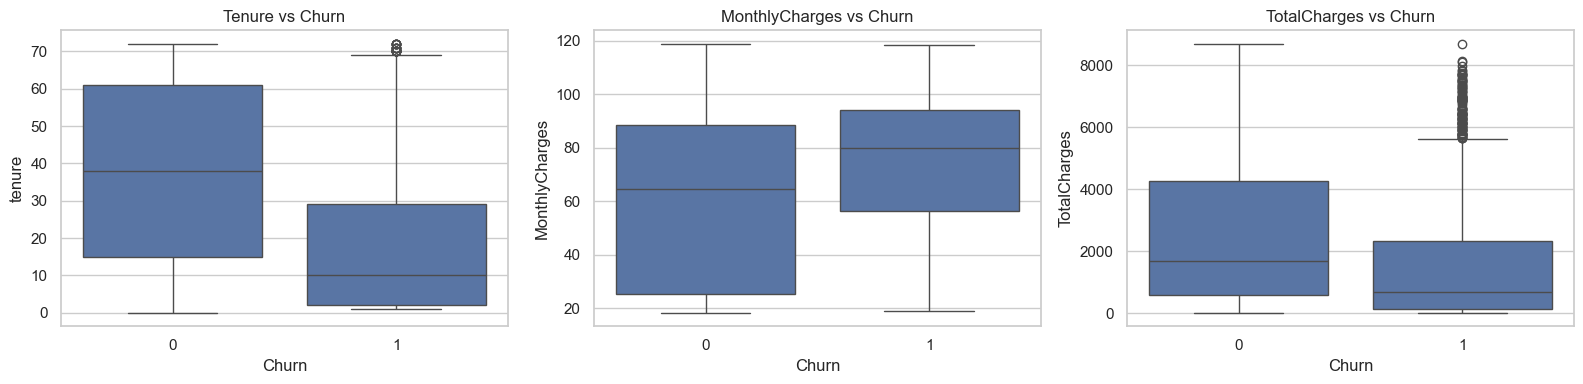

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0])
axes[0].set_title("Tenure vs Churn")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("MonthlyCharges vs Churn")

sns.boxplot(data=df, x="Churn", y="TotalCharges", ax=axes[2])
axes[2].set_title("TotalCharges vs Churn")

plt.tight_layout()

## Variables categóricas clave

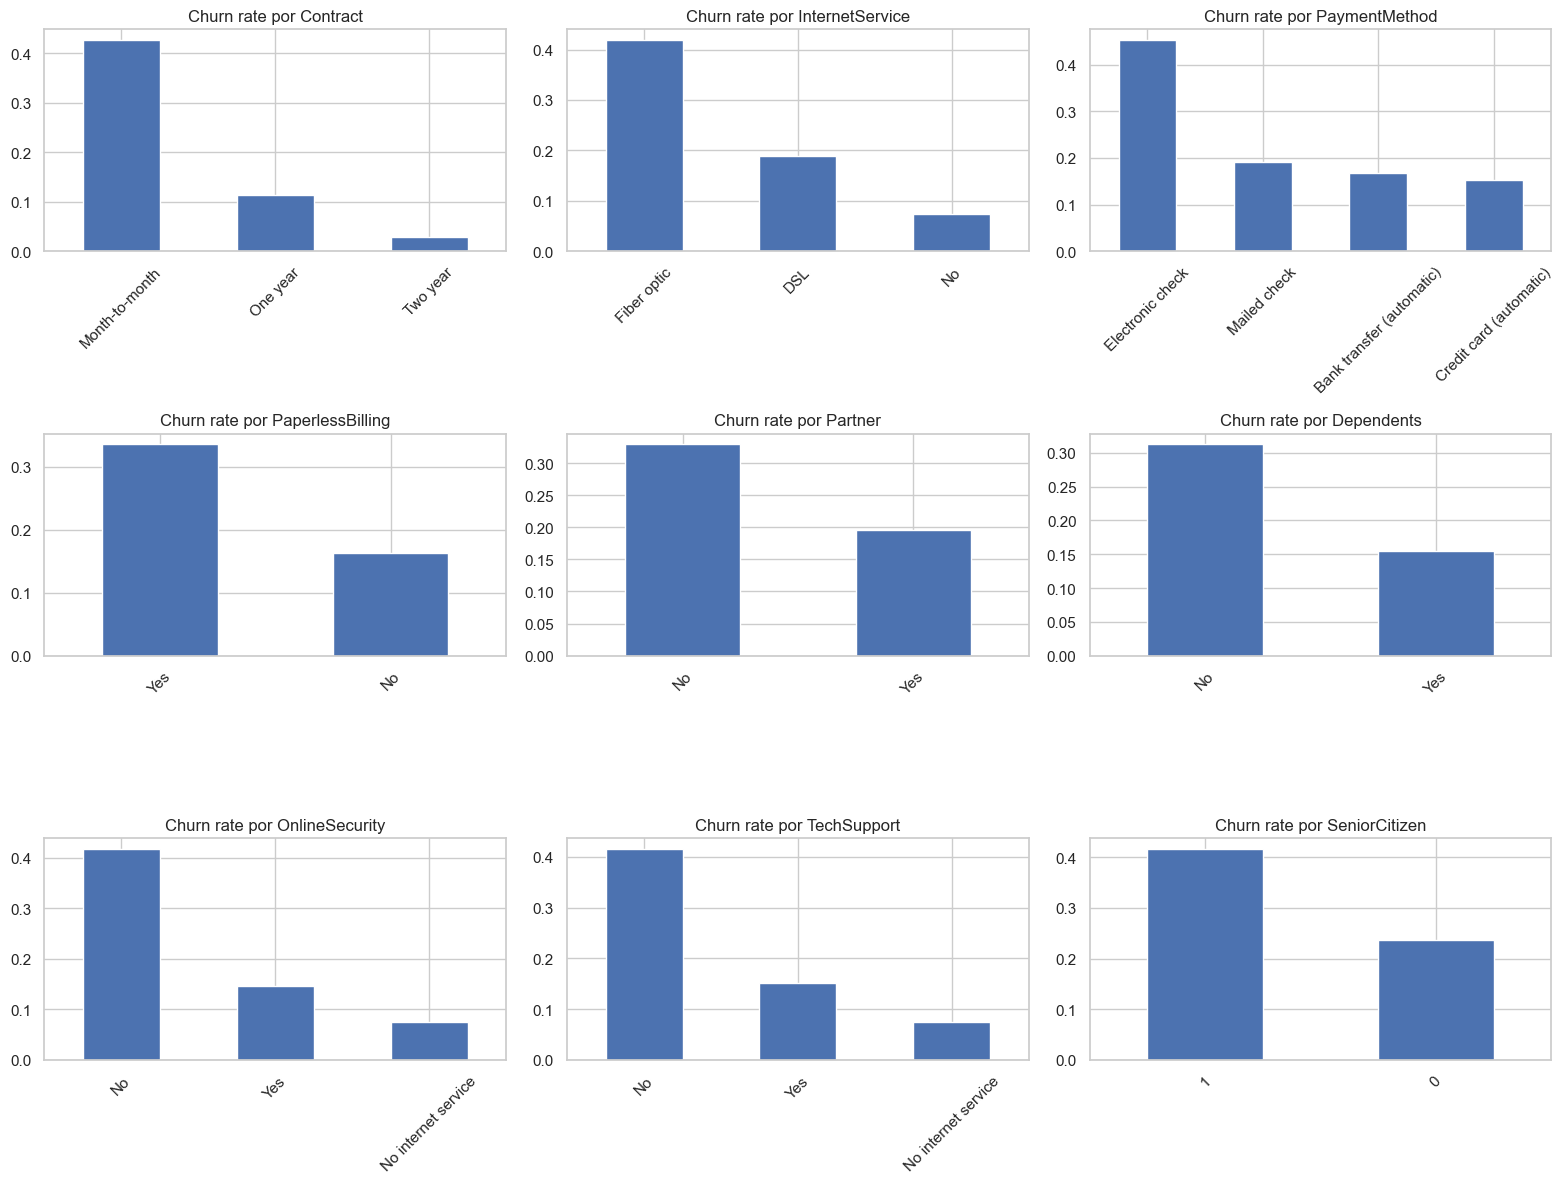

In [6]:
cat_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod", "SeniorCitizen"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(["Contract", "InternetService", "PaymentMethod", "PaperlessBilling", "Partner", "Dependents", "OnlineSecurity", "TechSupport", "SeniorCitizen"]):
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    churn_rate.plot(kind="bar", ax=axes[i], title=f"Churn rate por {col}")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()

## Feature engineering

In [7]:
df["AvgMonthlyCharge"] = df["TotalCharges"] / (df["tenure"] + 1)
df["HasPhoneService"] = (df["PhoneService"] == "Yes").astype(int)
df["HasInternet"] = (df["InternetService"] != "No").astype(int)
df["HasStreaming"] = ((df["StreamingTV"] == "Yes") | (df["StreamingMovies"] == "Yes")).astype(int)
df["HasSupport"] = ((df["TechSupport"] == "Yes") | (df["OnlineSecurity"] == "Yes")).astype(int)
df["LongTenure"] = (df["tenure"] > 24).astype(int)

display(df[["AvgMonthlyCharge", "HasPhoneService", "HasInternet", "HasStreaming", "HasSupport", "LongTenure"]].head())

,AvgMonthlyCharge,HasPhoneService,HasInternet,HasStreaming,HasSupport,LongTenure
0,14.925000,0,1,0,0,0
1,53.985714,1,1,0,1,1
2,36.050000,1,1,0,1,0
3,40.016304,0,1,0,1,1
4,50.550000,1,1,0,0,0


## Separar variables

In [8]:
target = "Churn"
id_col = "customerID"

X = df.drop(columns=[target, id_col])
y = df[target]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharge', 'HasPhoneService', 'HasInternet', 'HasStreaming', 'HasSupport', 'LongTenure']
Categóricas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Preprocesado

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

## Split train/test

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(5634, 25) (1409, 25)
0.2653532126375577 0.2654364797728886


## Baseline con regresión logística

In [11]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.846952905009171
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.51      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409



## Matriz de confusión

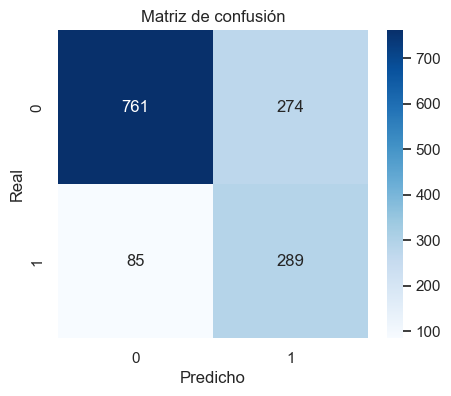

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

## Curva ROC y PR

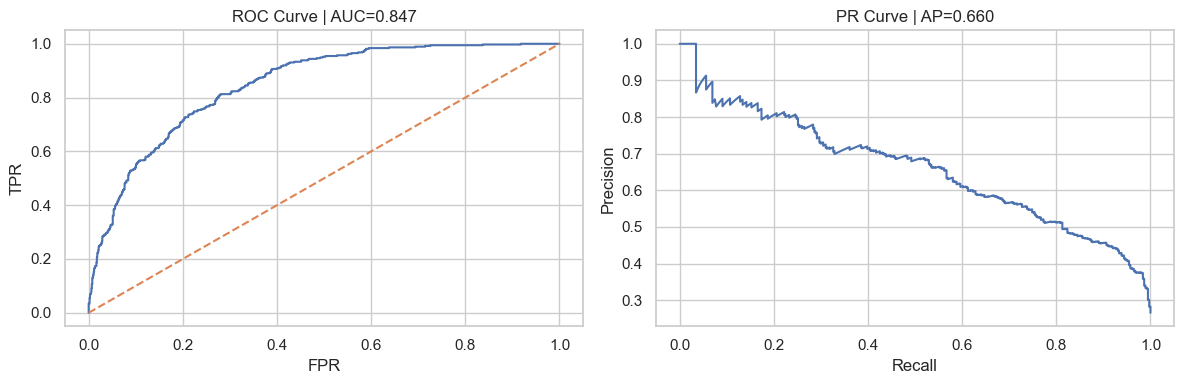

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], "--")
plt.title(f"ROC Curve | AUC={roc_auc_score(y_test, y_proba):.3f}")
plt.xlabel("FPR")
plt.ylabel("TPR")

plt.subplot(1,2,2)
plt.plot(rec, prec)
plt.title(f"PR Curve | AP={average_precision_score(y_test, y_proba):.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.tight_layout()
plt.show()

## Prueba otro modelo

In [14]:
lgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        random_state=42,
        class_weight="balanced"
    ))
])

lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba_lgb))
print(classification_report(y_test, y_pred_lgb))

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 940
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
ROC-AUC: 0.832637112816141
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1035
           1       0.53      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



## Comparar modelos

In [15]:
results = pd.DataFrame({
    "model": ["LogisticRegression", "LightGBM"],
    "roc_auc": [roc_auc_score(y_test, y_proba), roc_auc_score(y_test, y_proba_lgb)]
})

display(results.sort_values("roc_auc", ascending=False))

,model,roc_auc
0,LogisticRegression,0.846953
1,LightGBM,0.832637


## Importancia de variables

,feature,importance
1,num__MonthlyCharges,2967
2,num__TotalCharges,2729
3,num__AvgMonthlyCharge,2517
0,num__tenure,2020
9,cat__gender_Female,351
50,cat__PaymentMethod_Electronic check,336
7,num__HasSupport,255
28,cat__OnlineBackup_No,229
44,cat__Contract_One year,194
46,cat__PaperlessBilling_No,192


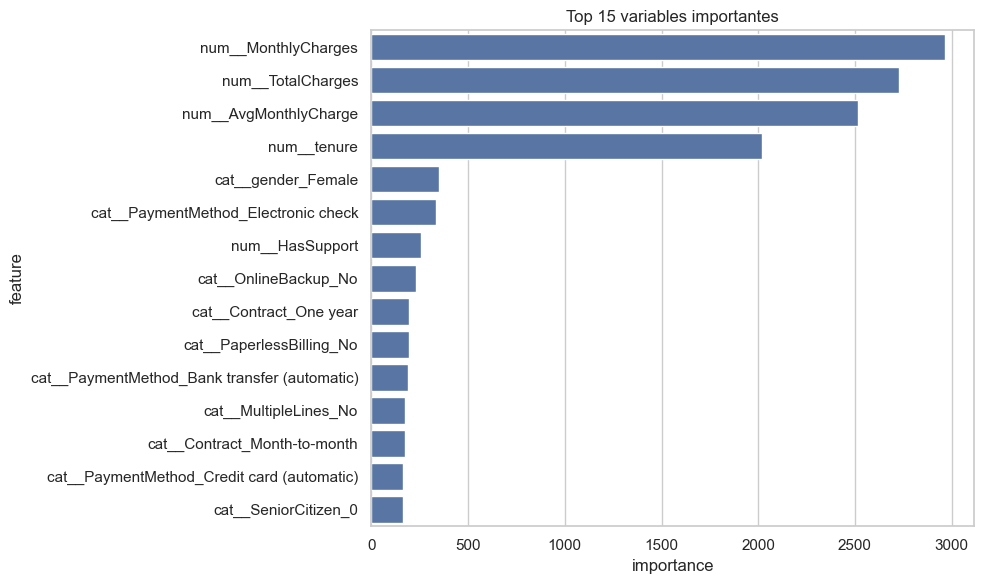

In [16]:
feature_names = lgb_model.named_steps["preprocessor"].get_feature_names_out()
importances = lgb_model.named_steps["model"].feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(fi.head(20))

plt.figure(figsize=(10,6))
sns.barplot(data=fi.head(15), x="importance", y="feature")
plt.title("Top 15 variables importantes")
plt.tight_layout()
plt.show()

In [ ]:
top_features = fi.head(10)

print("=== MOTIVOS PRINCIPALES DE CHURN ===")
for i, row in top_features.iterrows():
    feature = row["feature"]
    imp = row["importance"]
    
    if "MonthlyCharges" in feature or "AvgMonthlyCharge" in feature:
        print(f"💰 PRECIO ({imp:.0f}): Clientes sensibles al coste mensual")
    elif "TotalCharges" in feature:
        print(f"💸 ACUMULADO ({imp:.0f}): Facturas altas cansan")
    elif "tenure" in feature:
        print(f"👶 NUEVOS ({imp:.0f}): Clientes primer año volátiles")
    elif "Electronic" in feature:
        print(f"💳 PAGO ({imp:.0f}): Cheque electrónico = inestabilidad")
    elif "HasSupport" in feature:
        print(f"📞 SOPORTE ({imp:.0f}): Falta de TechSupport = insatisfacción")
    
    print(f"   Acción: {'Ofertas económicas' if 'Charges' in feature else 'Atención personalizada'}")
    print()

=== MOTIVOS PRINCIPALES DE CHURN ===
💰 PRECIO (2967): Clientes sensibles al coste mensual
   Acción: Ofertas económicas

💸 ACUMULADO (2729): Facturas altas cansan
   Acción: Ofertas económicas

💰 PRECIO (2517): Clientes sensibles al coste mensual
   Acción: Atención personalizada

👶 NUEVOS (2020): Clientes primer año volátiles
   Acción: Atención personalizada

   Acción: Atención personalizada

💳 PAGO (336): Cheque electrónico = inestabilidad
   Acción: Atención personalizada

📞 SOPORTE (255): Falta de TechSupport = insatisfacción
   Acción: Atención personalizada

   Acción: Atención personalizada

   Acción: Atención personalizada

   Acción: Atención personalizada



## Ajustar umbral

In [18]:
threshold = 0.35
y_pred_thr = (y_proba_lgb >= threshold).astype(int)

print(classification_report(y_test, y_pred_thr))
print("Threshold usado:", threshold)

              precision    recall  f1-score   support

           0       0.92      0.70      0.79      1035
           1       0.50      0.84      0.63       374

    accuracy                           0.73      1409
   macro avg       0.71      0.77      0.71      1409
weighted avg       0.81      0.73      0.75      1409

Threshold usado: 0.35


## Ejemplo de uso real

In [19]:
predictions = pd.DataFrame({
    "customerID": X_test.index,
    "churn_prob": y_proba_lgb
}).sort_values("churn_prob", ascending=False)

display(predictions.head(20))

,customerID,churn_prob
618,6623,0.987082
1259,2464,0.977843
940,5826,0.975718
171,2194,0.975604
733,3536,0.974919
604,85,0.973960
484,1568,0.969937
1090,3380,0.969676
1109,4585,0.968991
1289,1731,0.968573
